$$\text{Lorenz's Butterfly Plot, a.k.a., Birth of Chaos Theory}$$
$\text{Today I worked around lorenz equation. It is used in weather forecasting.}$
$\text{It is special because it is not random, but chaotic.}$
$\text{It is a very simple/primitive visuallization, as the underlying mathematical concept is very deep}$

In [33]:
import numpy as np
import sympy as smp
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from matplotlib import animation

In [34]:
t = smp.symbols('t')
x, y, z = smp.symbols('x y z')

In [35]:
dx = 10 * (y - x)
dy = x * (28 - z) - y
dz = x * y - smp.Rational(8, 3) * z

In [36]:
lorenz_N = smp.lambdify((t, (x, y, z)), (dx, dy, dz), 'numpy')

In [37]:
t_span = (0, 25)
t_eval = np.linspace(0, 25, 5001)
ini_cond = [1.0, 1.0, 1.0]

In [38]:
len(t_eval <1)

5001

In [39]:
sol = solve_ivp(lorenz_N, t_span, ini_cond, t_eval=t_eval)
xsol, ysol, zsol = sol.y

Text(0, 50.283665564336054, ' z')

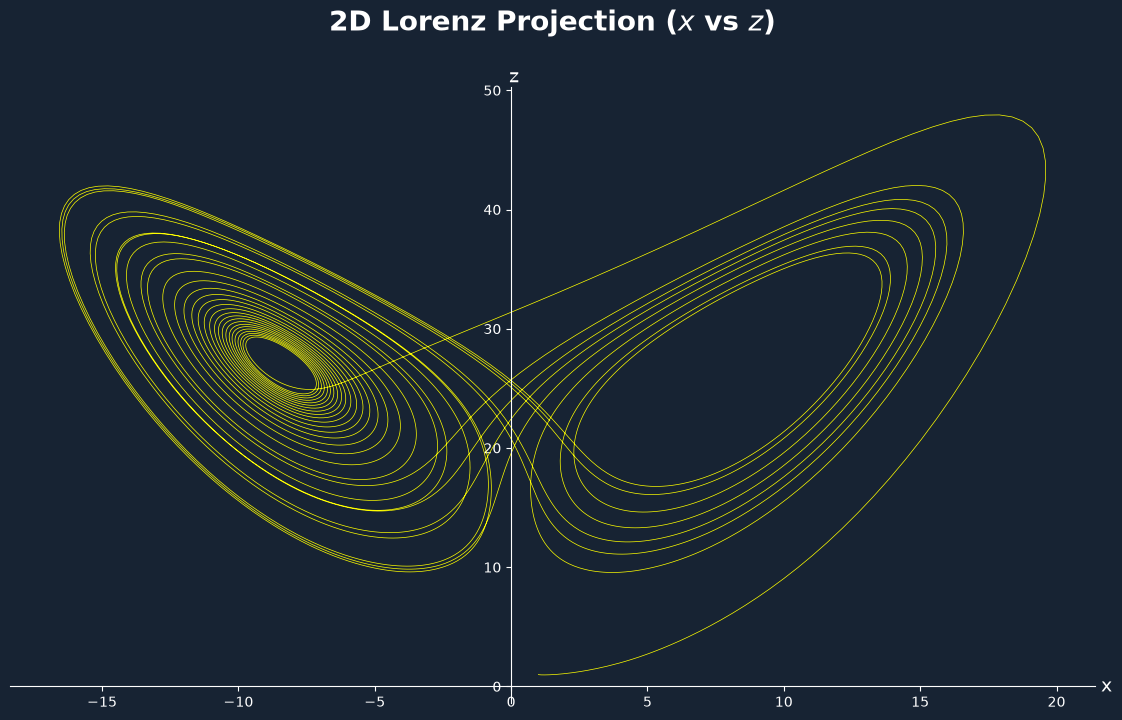

In [40]:
fig, ax = plt.subplots(1, 1, figsize=(14, 8), facecolor='#172333', )
ax.plot(xsol, zsol, color="#FFFF00", lw=0.5)
ax.set_facecolor('#172333')
ax.set_title("2D Lorenz Projection ($x$ vs $z$)", color='w', fontsize=20, fontweight='bold', pad=40)

ax.spines['bottom'].set_position(('data', 0))
ax.spines['left'].set_position(('data', 0))
ax.spines['bottom'].set_color('white')
ax.spines['left'].set_color('white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.tick_params(axis='x', colors='white', labelsize=10)
ax.tick_params(axis='y', colors='white', labelsize=10)

xlim = ax.get_xlim()
ylim = ax.get_ylim()
ax.text(xlim[1], 0, " x", color='w', fontsize=14, va='center', ha='left')
ax.text(0, ylim[1], " z", color='w', fontsize=14, va='bottom', ha='center')

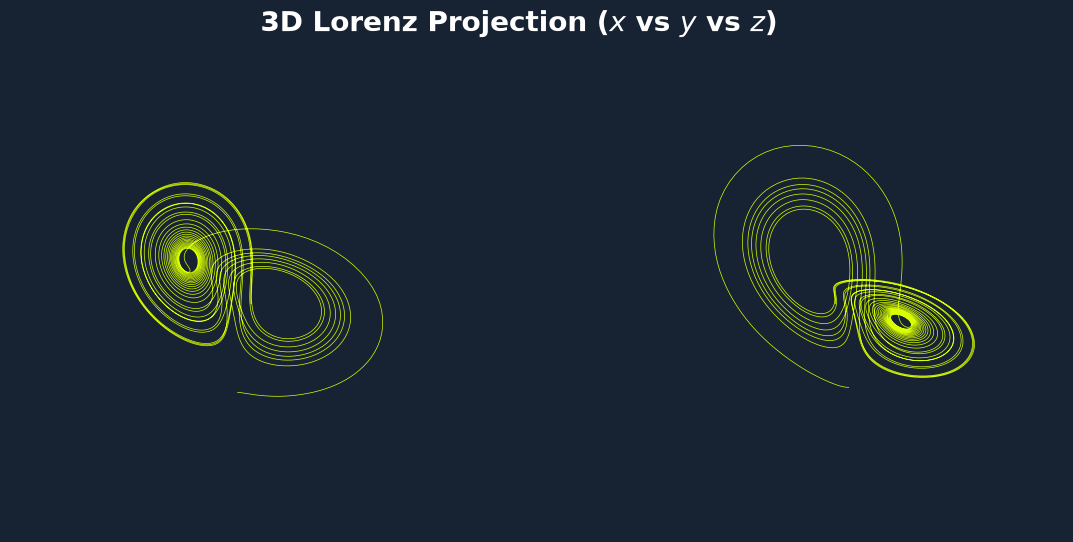

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), subplot_kw={'projection':'3d'}, facecolor='#172333')
fig.suptitle("3D Lorenz Projection ($x$ vs $y$ vs $z$)", color='w', fontsize=20, fontweight='bold')

ax = axes[0]
ax.plot(xsol, ysol, zsol, color="#D9FF00", lw=0.5)
ax.set_facecolor('#172333')
ax.view_init(elev=20, azim=0)
ax.set_axis_off() 


ax = axes[1]
ax.plot(xsol, ysol, zsol, color="#D9FF00", lw=0.5)
ax.set_facecolor('#172333')
ax.set_axis_off() 
ax.view_init(elev=30, azim=180)

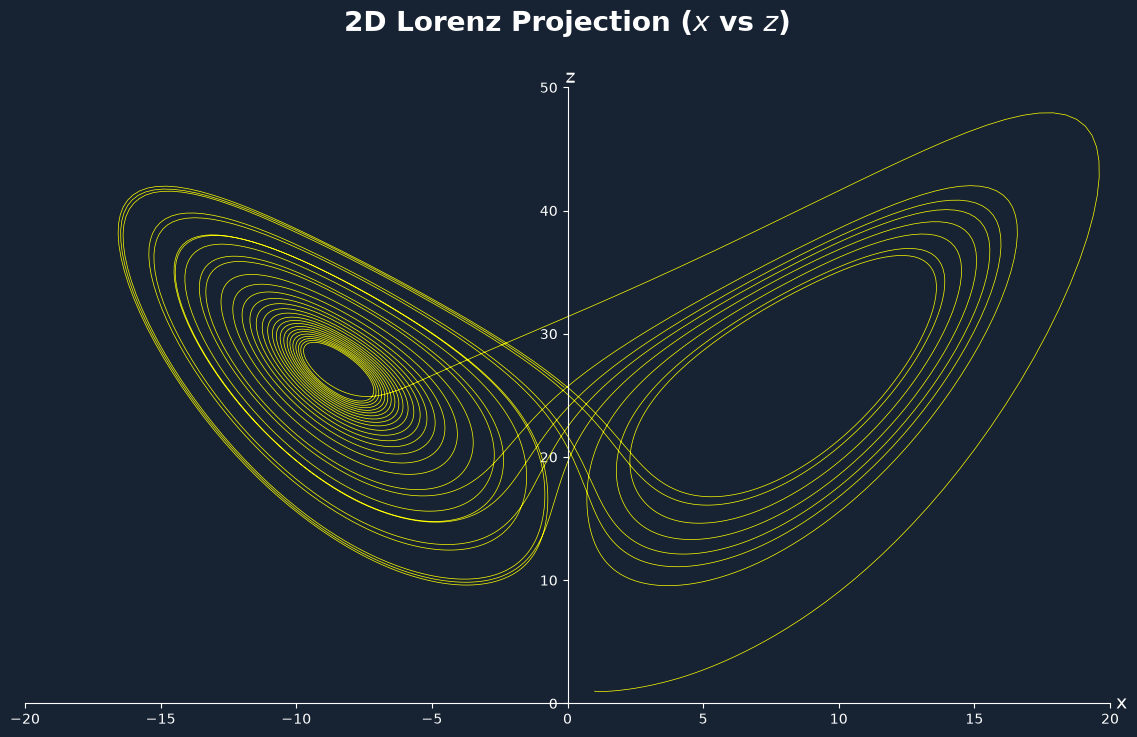

In [42]:
def animate(i):
    step = i * 10
    ln.set_data(xsol[:step], zsol[:step])
    return ln,

fig, ax = plt.subplots(1, 1, figsize=(14, 8), facecolor='#172333', )
ax.set_facecolor('#172333')
ax.set_title("2D Lorenz Projection ($x$ vs $z$)", color='w', fontsize=20, fontweight='bold', pad=40)

ln, = ax.plot([], [], color="#FFFF00", lw=0.5)

ax.spines['bottom'].set_position(('data', 0))
ax.spines['left'].set_position(('data', 0))
ax.spines['bottom'].set_color('white')
ax.spines['left'].set_color('white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.tick_params(axis='x', colors='white', labelsize=10)
ax.tick_params(axis='y', colors='white', labelsize=10)

ax.set_xlim(-20, 20)
ax.set_ylim(0, 50)

xlim = ax.get_xlim()
ylim = ax.get_ylim()
ax.text(xlim[1], 0, " x", color='w', fontsize=14, va='center', ha='left')
ax.text(0, ylim[1], " z", color='w', fontsize=14, va='bottom', ha='center')

ani = animation.FuncAnimation(fig, animate, frames=500, interval=20, blit=True)
ani.save('lorenz_attractor.gif', writer='pillow', fps=50)

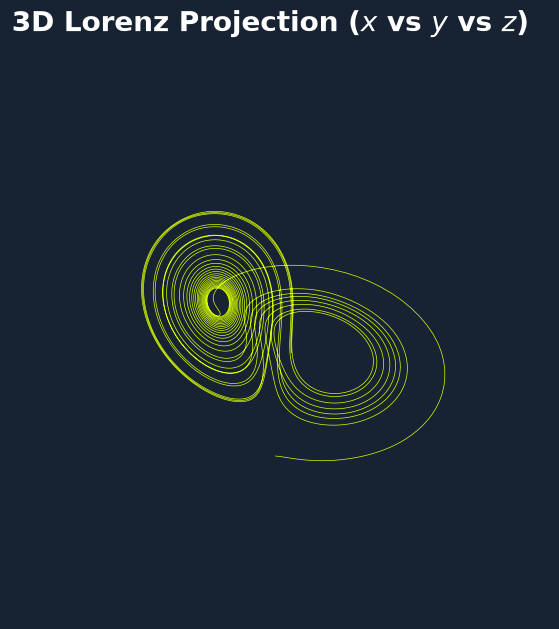

In [43]:
fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={'projection':'3d'}, facecolor='#172333',)
fig.suptitle("3D Lorenz Projection ($x$ vs $y$ vs $z$)", color='w', fontsize=20, fontweight='bold')
ax.plot(xsol, ysol, zsol, color="#D9FF00", lw=0.5)
ax.set_facecolor('#172333')
ax.set_axis_off() 
def update(frame):
    ax.view_init(elev=20, azim=frame)
    return fig,

ani = animation.FuncAnimation(fig, update, frames=np.arange(0, 360, 1), interval=20, blit=False)
ani.save('lorenz_attractor_3d.gif', writer='pillow', fps=50)

This file has two gif files, plz do watch them. They are placed inside media folder as lorenz_attractor.gif and lorenz_attractor_3d.gif 

the inspiration of making this came from a video made by 'Gonkee', https://www.youtube.com/watch?v=uzJXeluCKMs